In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import corner
from copy import deepcopy
from matplotlib import gridspec
import glob
from tqdm import tqdm
from scipy.stats import dirichlet
from scipy.stats import kstest
import seaborn as sns

sys.path.append('../../../AMAZE_model_selection/')
from populations.models import *
from itertools import product

/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
 def get_popsynth_outputs(file_path, chnl, channel_dict, param_dict, spinmag=None):
    deepest_models, hyperparam_pts_per_dim = get_deepest_models(file_path, channel_dict)
    channel_smdls, smdl_indxs_combos = get_channel_smdls(chnl, deepest_models, hyperparam_pts_per_dim)
    popsynth_outputs = read_hdf5(file_path, chnl, channel_smdls, smdl_indxs_combos, param_dict, spinmag)
    return popsynth_outputs

def load_models(channel_label):
    popsynth_outputs = get_popsynth_outputs(_models_path, channel_label, _channels_dict, _param_dict, spinmag=None)
    models_dict = dict.fromkeys(popsynth_outputs.keys())
    weights_dict = dict.fromkeys(popsynth_outputs.keys())
    for key in popsynth_outputs.keys():
        models_dict[key] = popsynth_outputs[key][list(_param_dict.keys())]
        weights_dict[key]= popsynth_outputs[key]['weight']
    return models_dict, weights_dict

In [3]:
_models_path ='/data/wiay/2297403c/models_reduced.hdf5'

_param_dict = {'mchirp' : {'limits':(0,100), 'fullname':'Chirp Mass [$M_\\odot$]'},
    'q' : {'limits':(0,1), 'fullname':'Mass Ratio'},
    'chieff' : {'limits':(-1,1), 'fullname':'Effective Inspiral Spin'},
    'z' : {'limits':(0,10), 'fullname':'Redshift'},
    }
_hyperparam_dict = {'chib' : {'values':{'chi00':0.0, 'chi01':0.1, 'chi02':0.2, 'chi05':0.5},
        'fullname':'$\\chi_\\mathrm{birth}$',
        'transform':'linear'},
    'alphaCE' : {'values':{'alpha02':0.2, 'alpha05':0.5, 'alpha10':1.0, 'alpha20':2.0, 'alpha50':5.0},
        'fullname':'$\\alpha_\\mathrm{CE}$',
        'transform':'log'}
    }
_channels_dict = {
    'CE':  {'parameters':['chib','alphaCE'], 'fullname':'Common Envelope'},
    'CHE': {'parameters':['chib'], 'fullname':'Chemically Homogeneous Evolution'},
    'GC':  {'parameters':['chib'], 'fullname':'Globular Clusters'},
    'NSC': {'parameters':['chib'], 'fullname':'Nuclear Star Clusters'},
    'SMT': {'parameters':['chib'], 'fullname':'Stable Mass Transfer'}
    }
use_flows = True

model_names, flow = get_models(_models_path, _channels_dict, _param_dict, _hyperparam_dict,\
         use_flows=True, sensitivity='midhighlatelow', spinmag=None, random_seed=12)
_, KDEs = get_models(_models_path, _channels_dict, _param_dict, _hyperparam_dict,\
             use_flows=False, sensitivity='midhighlatelow', spinmag=None, max_samps=None, kde_bandwidth=None, \
                        store_optimal_snrs=False, random_seed=12)

  0%|          | 0/36 [00:00<?, ?it/s]OMP: Warning #96: Cannot form a team with 44 threads, using 42 instead.
OMP: Hint Consider unsetting KMP_DEVICE_THREAD_LIMIT (KMP_ALL_THREADS), KMP_TEAMS_THREAD_LIMIT, and OMP_THREAD_LIMIT (if any are set).
100%|██████████| 36/36 [07:51<00:00, 13.10s/it]


In [4]:
np.random.seed(12)

In [5]:
flow['CE'].load_model('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/inputs/flow_models/mixed_models')

In [9]:
flow_samps = flow['CE'].sample(np.array([0.,np.log(5.)]), N=100000)
KDE_samps = KDEs['CE']['chi00']['alpha50'].sample(100000)

Text(0, 0.5, 'p(chi_eff)')

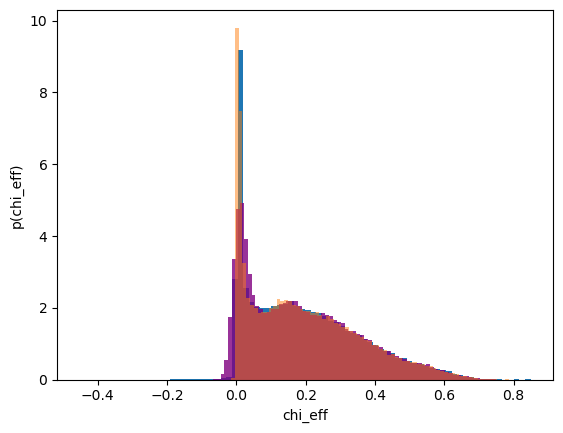

In [15]:
plt.hist(flow_samps[:,2], bins=80, density=True)
plt.hist(KDE_samps[:,2], bins=80, density=True, alpha=0.8, color='purple')
plt.hist(np.array(models_dict[(0,4)][:]['chieff']), weights=np.array(weights_dict[(0,4)]), bins=80, alpha=0.5, density=True)
plt.xlabel('chi_eff')
plt.ylabel('p(chi_eff)')

In [31]:
hist, bins = np.histogram(np.array(models_dict[(0,4)][:]['chieff']), weights=np.array(weights_dict[(0,4)]), bins=400)
hist_flow, bins_flow = np.histogram(flow_samps[:,2], bins=400)

In [18]:
#find weighted CDF of model samps
sort_idxs = np.argsort(models_dict[(0,4)][:]['chieff'])
sorted_samps = np.array(models_dict[(0,4)][:]['chieff'])[sort_idxs]
sorted_weights = np.array(weights_dict[(0,4)])[sort_idxs]

sort_idxs_flow = np.argsort(flow_samps[:,2])
sorted_samps_flow = flow_samps[sort_idxs_flow,2]

sort_idxs_KDE = np.argsort(KDE_samps[:,2])
sorted_samps_KDE= KDE_samps[sort_idxs_KDE,2]

all_samps = np.concatenate([sorted_samps, sorted_samps_flow])
cumweights = np.hstack([0, np.cumsum(sorted_weights)/sum(sorted_weights)])

cdf_modelsamps = cumweights[np.searchsorted(sorted_samps, all_samps, side='right')]
cdf_flow = np.searchsorted(sorted_samps_flow, all_samps, side='right') / flow_samps[:,2].shape[0]

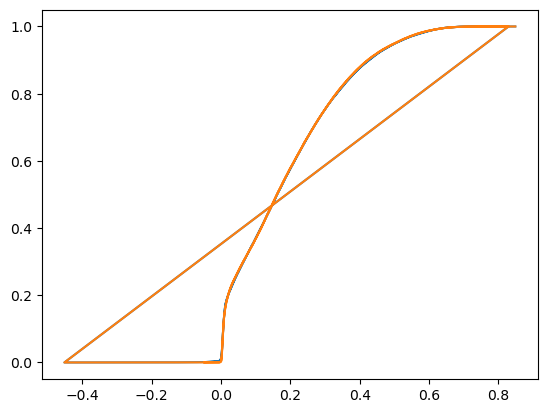

In [20]:
plt.plot(all_samps,cdf_flow)
plt.plot(all_samps,cdf_modelsamps)

Text(0, 0.5, 'CDF')

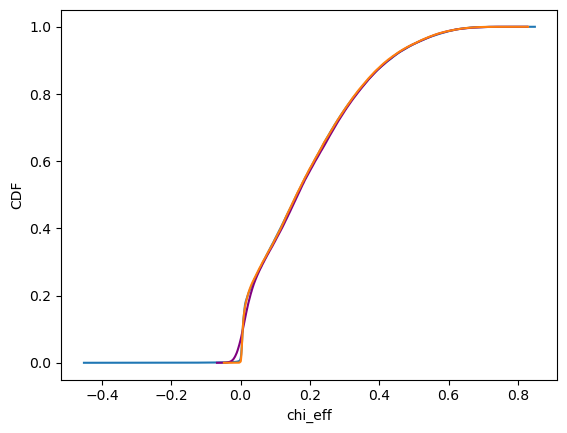

In [21]:
p = 1. * np.arange(len(flow_samps[:,2])) / (len(flow_samps[:,2]) - 1)
plt.plot(sorted_samps_flow, p)
p = 1. * np.arange(len(KDE_samps[:,2])) / (len(KDE_samps[:,2]) - 1)
plt.plot(sorted_samps_KDE, p, color='purple')
p = 1. * np.arange(len(sorted_samps)) / (len(sorted_samps) - 1)
plt.plot(sorted_samps, cumweights[1:])
"""plt.plot(bins[1:],np.cumsum(hist)/np.sum(hist))
plt.plot(bins_flow[1:],np.cumsum(hist_flow)/np.sum(hist_flow))
plt.plot(vals, stat)"""
plt.xlabel('chi_eff')
plt.ylabel('CDF')

In [10]:
#draw samples from popsynth by sample weight
weighted_samps = np.random.choice(np.array(models_dict[(0,4)][:]['chieff']), 100000, p=np.array(weights_dict[(0,4)])/np.sum(weights_dict[(0,4)]))
sort_idxs = np.argsort(weighted_samps)
sorted_samps = np.array(weighted_samps)[sort_idxs]

ks = kstest(weighted_samps, flow_samps[:,2])

In [13]:
ks

KstestResult(statistic=0.01082, pvalue=1.6345482996632727e-05, statistic_location=0.0006321370019577444, statistic_sign=-1)

In [12]:
kstest(weighted_samps, KDE_samps[:,2])

KstestResult(statistic=0.06595, pvalue=1.6128892296226547e-189, statistic_location=0.00037690847998117505, statistic_sign=-1)

In [6]:
chi_b = [0.,0.1,0.2,0.5]
alpha_CE = [0.2,.5,1.,2.,5.]
submodels_dict = {0: {0: 'chi00', 1: 'chi01', 2: 'chi02', 3: 'chi05'}, 1: {0: 'alpha02', 1: 'alpha05', 2: 'alpha10', 3: 'alpha20', 4: 'alpha50'}}

In [7]:
models_dict, weights_dict = load_models('CE')

In [8]:
ks_flows = np.zeros((4,5))
ks_kdes = np.zeros((4,5))

for chib_id, xb in enumerate(chi_b):
    for alpha_id, a, in enumerate(alpha_CE):
        flow_samps = flow['CE'].sample(np.array([xb,np.log(a)]), N=100000)
        KDE_samps = KDEs['CE'][submodels_dict[0][chib_id]][submodels_dict[1][alpha_id]].sample(100000)
        model_samps=models_dict[(chib_id,alpha_id)][:]['chieff']
        weighted_samps = np.random.choice(model_samps, 100000, p=np.array(weights_dict[(chib_id,alpha_id)])/np.sum(weights_dict[(chib_id,alpha_id)]))
        ks_flows[chib_id,alpha_id]=(kstest(weighted_samps, flow_samps[:,2]))[0]
        ks_kdes[chib_id,alpha_id]=(kstest(weighted_samps, KDE_samps[:,2]))[0]

In [11]:
np.save('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224/data/CE_flow_KS.npy', ks_flows, allow_pickle=True)
np.save('/data/wiay/2297403c/amaze_model_select/Nflows_AMAZE_paper/plots/prod_091224/data/CE_KDE_KS.npy', ks_kdes, allow_pickle=True)

In [10]:
np.mean(ks_flows/ks_kdes)

0.11412826529755613

In [12]:
np.mean(ks_kdes/ks_flows)

9.807430287633128

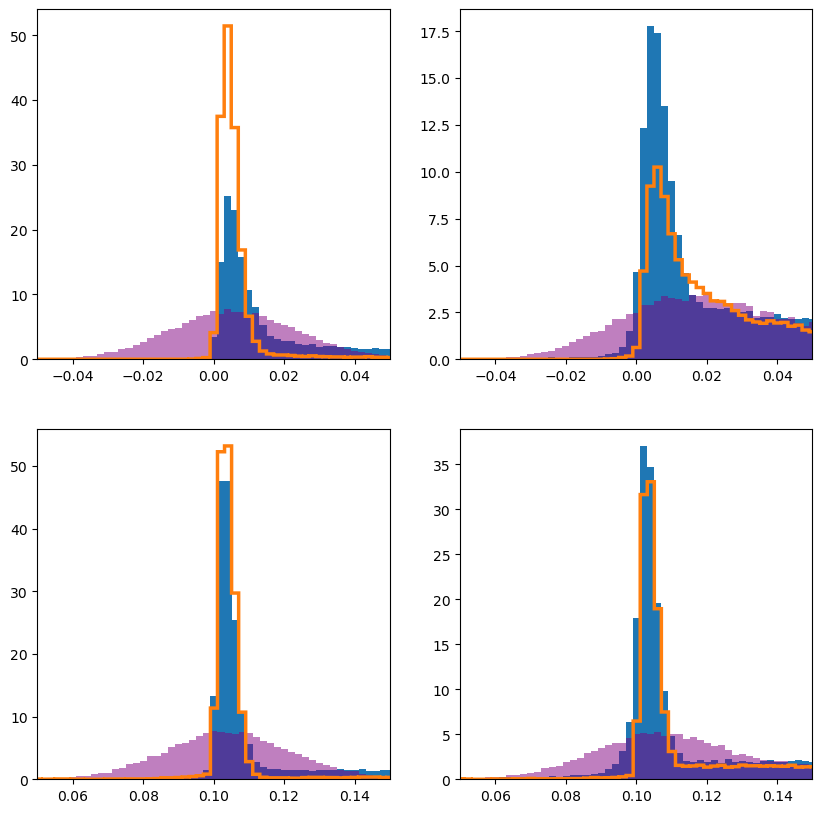

In [38]:
fig,ax = plt.subplots(2,2)
plt.rcParams["figure.figsize"] = (10,10)
for chib_id, xb in enumerate(chi_b):
    for alpha_id, a, in enumerate(alpha_CE):
        flow_samps = flow['CE'].sample(np.array([xb,np.log(a)]), N=100000)
        KDE_samps = KDEs['CE'][submodels_dict[0][chib_id]][submodels_dict[1][alpha_id]].sample(100000)
        bins = np.linspace(-1,1,1000)
        ax[chib_id,alpha_id].hist(flow_samps[:,2], bins=bins, density=True)
        ax[chib_id,alpha_id].hist(KDE_samps[:,2], bins=bins, density=True, color='purple', alpha=0.5)
        ax[chib_id,alpha_id].hist(np.array(models_dict[(chib_id,alpha_id)][:]['chieff']), weights=np.array(weights_dict[(chib_id,alpha_id)]),\
             bins=bins, density=True, histtype='step', lw=2.5)
        ax[chib_id,alpha_id].set_xlim(xb-0.05,xb+0.05)
